In [ ]:
import model.rag_code as rag_code
import pandas as pd
# %%
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.documents import Document
import time
from langchain.retrievers.multi_query import MultiQueryRetriever
# from langchain.chat_models import ChatOpenAI  # or use a local LLM
from langchain_groq import ChatGroq
import nanosurf
from sentence_transformers import SentenceTransformer
from openai import OpenAI
import os
from langchain.chat_models import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
llms = ["llama-3.3-70b-versatile", "deepseek-r1-distill-llama-70b","mistral-saba-24b"]
questions = pd.read_csv("question_AFM.csv")


c:\python3.12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# make 2 arrays of model and api keys and run a loop on them
llms = ["llama-3.3-70b-versatile", "deepseek-r1-distill-llama-70b","mistral-saba-24b"]
api_key_groq = os.getenv("GROQ_API_KEY")
api_key_gpt = os.getenv("OPENAI_API_KEY_PLANNER")
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma(
    persist_directory="./chroma_db",
    embedding_function=embedding_model)

time.sleep(300)
# llm_model = llms[1]

# llm = ChatGroq(
#    model=llm_model,
#     temperature=0,
#     max_retries=2,
#     model_kwargs={"top_p":1, "seed":1402},
#     stop=None,
#     api_key=api_key_groq
# )


llm_model = "gpt-3.5-turbo-0125"
llm = ChatOpenAI(model_name = llm_model, openai_api_key = api_key_gpt, temperature = 0)

retriever_wo = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 6},
)

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever= retriever_wo,  # from Chroma setup earlier
    llm=llm
)

nlp_model = SentenceTransformer("all-MiniLM-L6-v2")

C:\Users\megha\AppData\Local\Temp\ipykernel_28840\425964575.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
C:\Users\megha\AppData\Local\Temp\ipykernel_28840\425964575.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(
C:\Users\megha\AppData\Local\Temp\ipykernel_28840\

In [ ]:
# now i need to read the excel file questions and run them in get afm code
# for gpt only 
questions = pd.read_csv("~/questions/question_AFM.csv")

for index, row in questions.iterrows():
    time.sleep(30)
    if(index==1):
        query = row[0]
        with open(f"{llm_model}_output_{index}_try_for_time.txt", "w") as f:
            try:
                
                code_output, code_metadata,i,j, time = rag_code.generate_afm_code(query, multi_query_retriever, llm, nlp_model)
                print(code_output)
                
            # save the code output in a text file with the same name as the index or line number of the query
                f.write(f"Query : {query}\n\n")
                f.write(code_output)  # save it in a text file with same name as the index or line number of the query
                f.write(f"\n\n Metadata: {code_metadata}\n") # save it in a text file with same name as the index or line number of the query
                f.write(f"\n time for completion = {time}")
                f.close()
            except Exception as e:
                f.write(f"Error: {str(e)}\n")
                f.close()
        time.sleep(20)
        break


# excel file will have the query and avg scores for latency, token count

C:\Users\megha\AppData\Local\Temp\ipykernel_7584\3952431160.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  query = row[0]


['1. Access the AFM software interface.', '2. Locate the settings or configuration menu.', '3. Find the I gain parameter within the settings.', '4. Set the I gain value to 1000.', '5. Save the changes in the software interface.']

Step: 1. Access the AFM software interface.
  Description: Get the AFM sensor status.
  Function: ScanHead.AFMSensorStatus [read only]

Step: 2. Locate the settings or configuration menu.
  Description: This method sets the configuration file description.
  Function: BatchManager.SetConfigurationDescription(strDescription)

Step: 3. Find the I gain parameter within the settings.
  Description: Returns or set the integral gain of the user 0 controller.
  Function: SignalIO.User0IGain  [= gain]

Step: 4. Set the I gain value to 1000.
  Description: Returns or set the integral gain of the user 0 controller.
  Function: SignalIO.User0IGain  [= gain]

Step: 5. Save the changes in the software interface.
  Description: This method saves a batch manager configuratio

In [ ]:
llms = ["llama-3.3-70b-versatile", "deepseek-r1-distill-llama-70b","mistral-saba-24b"]

embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma(
    persist_directory="./chroma_db", 
    embedding_function=embedding_model
)
time.sleep(300)

In [ ]:
nlp_model = SentenceTransformer("all-MiniLM-L6-v2")

for llm_model in llms:
    llm = ChatGroq(
   model=llm_model,
    temperature=0,
    max_retries=2,
    model_kwargs={"top_p":1, "seed":1402},
    stop=None,
    api_key=api_key_groq
    )

    retriever_wo = vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": 6},
    )

    multi_query_retriever = MultiQueryRetriever.from_llm(
        retriever= retriever_wo,  # from Chroma setup earlier
        llm=llm
    )
        # now i need to read the excel file questions and run them in get afm code
    
    for index, row in questions.iterrows():
        time.sleep(30)
        if(index >= 16):
            query = row[0]
            with open(f"{llm_model}_output_{index-1}.txt", "w") as f:
                try:
                    code_output, code_metadata,i,j = rag_code.generate_afm_code(query, multi_query_retriever, llm, nlp_model)
                    print(code_output)
                # save the code output in a text file with the same name as the index or line number of the query
                    f.write(f"Query : {query}\n\n")
                    f.write(code_output)  
                    f.write(f"\n\n Metadata: {code_metadata}\n") 
                    f.close()
                except Exception as e:
                    f.write(f"Error: {str(e)}\n")
                    f.close()
            time.sleep(20)
            break



In [ ]:
# for llm output only

from langchain_core.prompts import PromptTemplate



# %%
standard_setup = """# Required imports and controller setup
import time
import nanosurf
spm = nanosurf.SPM()
app = spm.application
"""

standard_teardown = """# Clean up
del spm"""

instruction_set = """ #Instructions:
- Always begin with the setup code.                                     
- Use `spm` as the controller object.
- Use 'app' as the main_class object.                                             
- Use the teardown code at the end.
- All class types except 'main_class' are objects of the main class object. 
- Create them using  `object_name` in its exact same format from the field value in metadata.
- Always skip unrelated or duplicate steps.
- Add `time.sleep()` if a delay is implied.
- Print a status message after each step.
"""



code_template = PromptTemplate.from_template("""
You are a Python assistant that writes complete code for controlling a Nanosurf SPM system.

Given a user query and a set of function definitions, generate full working Python code to complete the task.
    
    Instructions:
{instructions}

User Query:
{query}

Setup Code:
{setup}

Teardown Code:
{teardown}

Write the full Python code below:
""")

llms = ["llama-3.3-70b-versatile", "deepseek-r1-distill-llama-70b","mistral-saba-24b"]

for llm_model in llms:
    time.sleep(300)
    llm = ChatGroq(
   model=llm_model,
    temperature=0,
    max_retries=2,
    model_kwargs={"top_p":1, "seed":1402},
    stop=None,
    api_key= api_key_groq
    )


# llm_model = "gpt-3.5-turbo-0125"
# llm = ChatOpenAI(model_name = llm_model, openai_api_key = api_key_gpt, temperature = 0)
for index, row in questions.iterrows():
            time.sleep(30)
            if(index >1):
                user_query = row[0]
                with open(f"{llm_model}_woRAG_{index}_wIns.txt", "w") as f:
                    try:
                        full_prompt = code_template.format(
                            instructions = instruction_set,
                            query = user_query,
                            setup=standard_setup,
                            teardown=standard_teardown   
                        )

                        response = llm.invoke(full_prompt)
                        code_output, code_metadata = response.content, response.response_metadata
                        print(code_output)
                    # save the code output in a text file with the same name as the index or line number of the query
                        f.write(f"Query : {user_query}\n\n")
                        f.write(code_output)  
                        f.write(f"\n\n Metadata: {code_metadata}\n") 
                        f.close()
                    except Exception as e:
                        f.write(f"Error: {str(e)}\n")
                        f.close()
                time.sleep(20)
                

C:\Users\megha\AppData\Local\Temp\ipykernel_24132\1989540069.py:69: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model_name = llm_model, openai_api_key = api_key_gpt, temperature = 0)
C:\Users\megha\AppData\Local\Temp\ipykernel_24132\1989540069.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  user_query = row[0]


```python
# Required imports and controller setup
import time
import nanosurf
spm = nanosurf.SPM()
app = spm.application

# Set the time per line to 1 second
app.set_time_per_line(1)
print("Time per line set to 1 second.")

# Clean up
del spm
```


C:\Users\megha\AppData\Local\Temp\ipykernel_24132\1989540069.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  user_query = row[0]


```python
# Required imports and controller setup
import time
import nanosurf
spm = nanosurf.SPM()
app = spm.application

# Set setpoint to 1 V in the AFM software
setpoint = app.setpoint
setpoint.value = 1.0
print("Setpoint set to 1 V")

# Clean up
del spm
```


C:\Users\megha\AppData\Local\Temp\ipykernel_24132\1989540069.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  user_query = row[0]


...

```python
# Required imports and controller setup
import time
import nanosurf
spm = nanosurf.SPM()
app = spm.application

# Capture a new slope corrected image
slope_corrected_image = app.image.slope_corrected_image()
time.sleep(2)  # Adding a delay for the image capture process

print("Slope corrected image captured successfully.")

# Clean up
del spm
```


C:\Users\megha\AppData\Local\Temp\ipykernel_24132\1989540069.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  user_query = row[0]


```python
# Required imports and controller setup
import time
import nanosurf
spm = nanosurf.SPM()
app = spm.application

# Set the image width for maximum movement of 500 um with an overscan of 10
app.image_width = 510

print("Image width set to 510 um for maximum movement of 500 um with an overscan of 10")

# Clean up
del spm
```


C:\Users\megha\AppData\Local\Temp\ipykernel_24132\1989540069.py:73: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  user_query = row[0]


```python
# Required imports and controller setup
import time
import nanosurf
spm = nanosurf.SPM()
app = spm.application

# Create objects
contour = app.contour

# Capture a new contour enabled image
contour.capture_image()

time.sleep(2)  # Adding a delay for the image capture process

print("New contour enabled image captured successfully.")

# Clean up
del spm
```


C:\Users\megha\AppData\Local\Temp\ipykernel_13480\2181883519.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if(row[1] == "b"):
C:\Users\megha\AppData\Local\Temp\ipykernel_13480\2181883519.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif(row[1] == "multi_b"):
C:\Users\megha\AppData\Local\Temp\ipykernel_13480\2181883519.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif(row[1] == "adv"):


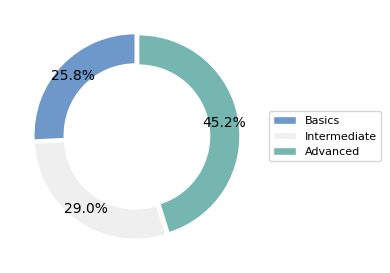

In [ ]:
# plots
#plot 1
import matplotlib.pyplot as plt

# Data
labels = ['Basics', 'Intermediate', 'Advanced']
size_b,size_mb,size_a = 0,0,0
for index, row in questions.iterrows():
    if(index>1):
        if(row[1] == "b"):
            size_b += 1
        elif(row[1] == "multi_b"):
            size_mb += 1
        elif(row[1] == "adv"):
            size_a += 1


sizes = [size_b, size_mb, size_a]
colors = ["#6e98c9", "#e6e6e6a0","#75b7b0"]  # Match the colors from your chart
explode = (0.02, 0.02, 0.02)  # Slightly separate the slices

# Create donut chart
fig, ax = plt.subplots(figsize = (4,4))
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=None,
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=90,
    wedgeprops=dict(width=0.3, edgecolor='white'),
    pctdistance=0.85,
    explode=explode
)
font = {'family':'Sans serif', 'size' : 8}
# Add legend
ax.legend(wedges, labels, title="", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), prop = font )

# Center circle to create donut
centre_circle = plt.Circle((0, 0), 0.10, fc='white')
fig.gca().add_artist(centre_circle)

# # Add subplot label "a"
# ax.text(-1.3, 1.2, "a", fontsize=20, fontweight='bold')

# Add chart title
# ax.set_title("Task types", loc='left', fontsize=14)
# plt.savefig('question_categories.pdf')
plt.tight_layout()
plt.show()



In [8]:
print(sizes)

[8, 9, 14]


In [5]:
import numpy as np
deepseek_results = pd.read_csv("question_AFM_deepseek_fin.csv")

gpt_results = pd.read_csv("question_AFM_gpt_fin.csv")

llama_results = pd.read_csv("question_AFM_llama_fin.csv")

mistral_results = pd.read_csv("question_AFM_mistral_fin.csv")


In [15]:
def get_avg_scores(csv_file):
    acc_b, acc_mb, acc_adv = 0,0,0
    hal_b,hal_mb,hal_adv=0,0,0
    token_b, token_mb, token_adv=0,0,0
    cnt_b,cnt_mb, cnt_adv =0,0,0
    t_b, t_mb, t_adv = 0,0,0
    code_err_b,code_err_mb,code_err_a =0,0,0 #code eeror and wrong wrong function
    for index, row in csv_file.iterrows():
        if(index>=1):
            task_type= row[1]
           
            
            score = 1 if (row[2]=='y' or row[3]=='y' or row[4]=='y') else 0
            
            if(task_type == "b"):
                
                acc_b += score
                # print(row[6])
                hal_b += float(row[7])
                code_err_b+=float(row[6])
                if(score == 1):
                    cnt_b +=1
                    token_b+=float(row[9])
                    t_b += float(row[8] )
            elif(task_type == "multi_b"):
                acc_mb += score
                hal_mb += float(row[7])
                code_err_mb+=float(row[6])
                if(score == 1):
                    cnt_mb +=1
                    token_mb+=float(row[9])
                    t_mb += float(row[8] )
            elif(task_type == "adv"):
                acc_adv += score
                hal_adv += float(row[7])
                code_err_a+=float(row[6])
                if(score == 1):
                    cnt_adv +=1
                    token_adv+=float(row[9])
                    t_adv += float(row[8] )
    accuracy_array = [(acc_b/size_b)*100 , (acc_mb/size_mb)*100 , (acc_adv/size_a)*100 ]
    hal_array = [(hal_b / size_b) * 100 ,(hal_mb / size_mb) * 100 ,(hal_adv / size_a) * 100 ]
    raw_score = acc_b + acc_mb + acc_adv
    token_arr = [token_b/cnt_b, token_mb/cnt_mb, token_adv/cnt_adv]
    time_p_1000_tokens = [t_b/(token_b/1000), t_mb/(token_mb/1000), t_adv/(token_adv/1000)]
    avg_time_arr = [t_b/cnt_b, t_mb/cnt_mb, t_adv/cnt_adv]
    code_err_arr = [(code_err_b/size_b)*100,(code_err_mb/size_mb)*100, (code_err_a/size_a)*100] 
    total_err_arr = [ size_b - cnt_b,size_mb - cnt_mb,size_a - cnt_adv]
    total_tokens = (token_b+token_mb+token_adv)/(cnt_b+cnt_mb+cnt_adv)
    total_latency =  (t_b + t_mb + t_adv)/(cnt_b+cnt_mb+cnt_adv)
    return accuracy_array, hal_array , token_arr , time_p_1000_tokens ,  avg_time_arr, code_err_arr, total_err_arr, raw_score,total_tokens,total_latency





In [26]:
#plot 2
ds_acc, ds_hal , ds_tokens , ds_time_per1000_token, ds_latency, ds_code_err,ds_total_err, total_acc_ds,tot_tk_ds,tot_lat_ds = get_avg_scores(deepseek_results)
gpt_acc, gpt_hal , gpt_tokens ,gpt_time_per1000_token, gpt_latency, gpt_code_err,gpt_total_err,total_acc_gpt ,tot_tk_gpt,tot_lat_gpt= get_avg_scores(gpt_results)
llama_acc, llama_hal , llama_tokens , llama_time_per1000_token, llama_latency, llama_code_err,llama_total_err,total_acc_llama,tot_tk_llama,tot_lat_llama = get_avg_scores(llama_results)
mst_acc, mst_hal , mst_tokens , mst_time_per1000_token, mst_latency , mst_code_err,mst_total_err, total_acc_mst,tot_tk_mst,tot_lat_mst = get_avg_scores(mistral_results)
print(get_avg_scores(deepseek_results))
print(get_avg_scores(llama_results))
print(get_avg_scores(mistral_results))
print(get_avg_scores(gpt_results))
model_colors = ["#1f5486", "#408dae", "#2fa6b1","#bba2a264"]
models = ['Deepseek_R1','GPT-3.5', 'Llama-3.3', 'Mistral_saba']

acc_data = np.array([ds_acc,gpt_acc, llama_acc,mst_acc])
hal_data = np.array([ds_hal,gpt_hal,llama_hal,mst_hal])
token_data = np.array([ds_tokens,gpt_tokens, llama_tokens,mst_tokens])
time_per1000token_data = np.array([ds_time_per1000_token,gpt_time_per1000_token, llama_time_per1000_token,mst_time_per1000_token])
avg_latency = np.array([ds_latency, gpt_latency, llama_latency,mst_latency])

err_code = np.array([ds_code_err,gpt_code_err,llama_code_err,mst_code_err])




    

def plot_settings (models,data,model_colors, plot_x):
    bar_height = 0.15
    x = np.arange(3)
    plt.figure(figsize=(4,5))
    ax = plt.gca()
    font = {'family':'Sans serif', 'size' : 8}
    gap = 0.03  # white space gap between bars

    # Centered y positions with spacing
    offsets = np.linspace(-((len(models)-1)/2), ((len(models)-1)/2), len(models)) * (bar_height + gap)
    positions = [x + offset for offset in offsets]



    for i in range(len(models)):
        ax.bar(
            positions[i], data[i]+0.05,
            label=models[i],
            width = bar_height,
            color=model_colors[i]
        )
    ax.tick_params(direction='in')
    ax.set_xticks(x)
    ax.set_xticklabels(labels,fontdict=font)
    if("%" in plot_x):
        ax.set_yticklabels(np.arange(0,110,10), fontdict=font)
    
    ax.set_ylabel(plot_x, fontdict=font)
    # ax.invert_yaxis()  # Highest category at the top
    ax.legend(prop = font)
    # plt.savefig(f"{plot_x}.pdf")
    plt.tight_layout()
    plt.show()


([62.5, 33.33333333333333, 50.0], [25.0, 18.555555555555557, 9.5], [2999.4, 4483.333333333333, 4126.571428571428], [0.7247449489897979, 0.5927881040892193, 0.6802949525721804], [2.1738, 2.6576666666666666, 2.807285714285715], [74.875, 70.33333333333334, 57.07142857142857], [3, 6, 7], 15, 3822.2, 2.5662000000000003)
([37.5, 44.44444444444444, 42.857142857142854], [50.0, 51.77777777777778, 59.57142857142858], [1123.0, 1327.75, 1366.3333333333333], [0.7289997031760166, 1.0138392016569382, 0.6965113442303], [0.8186666666666667, 1.3461249999999998, 0.9516666666666667], [37.5, 29.555555555555557, 23.785714285714285], [5, 5, 8], 13, 1298.3076923076924, 1.0423461538461538)
([50.0, 22.22222222222222, 14.285714285714285], [75.0, 92.55555555555556, 28.57142857142857], [1348.25, 1148.0, 1524.0], [0.7075839050621174, 0.7029616724738676, 0.9488188976377953], [0.9539999999999998, 0.8069999999999999, 1.446], [12.5, 0.0, 42.857142857142854], [4, 7, 12], 8, 1342.125, 1.04025)
([37.5, 44.44444444444444, 

C:\Users\megha\AppData\Local\Temp\ipykernel_13480\3448106355.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  task_type= row[1]
C:\Users\megha\AppData\Local\Temp\ipykernel_13480\3448106355.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  score = 1 if (row[2]=='y' or row[3]=='y' or row[4]=='y') else 0
C:\Users\megha\AppData\Local\Temp\ipykernel_13480\3448106355.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hal_b += flo

C:\Users\megha\AppData\Local\Temp\ipykernel_13480\3501439456.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.arange(0,110,10), fontdict=font)


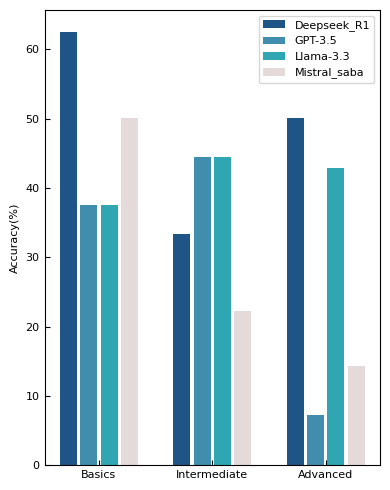

C:\Users\megha\AppData\Local\Temp\ipykernel_13480\3501439456.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.arange(0,110,10), fontdict=font)


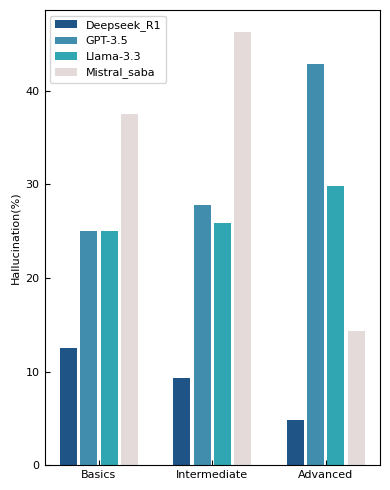

C:\Users\megha\AppData\Local\Temp\ipykernel_13480\3501439456.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.arange(0,110,10), fontdict=font)


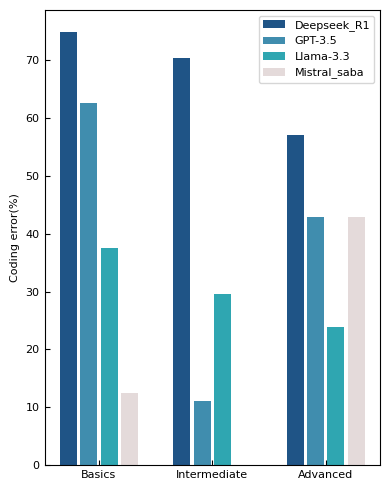

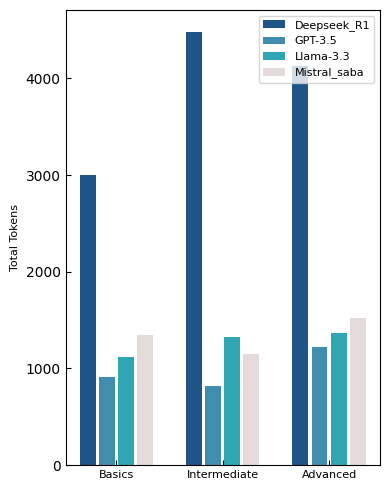

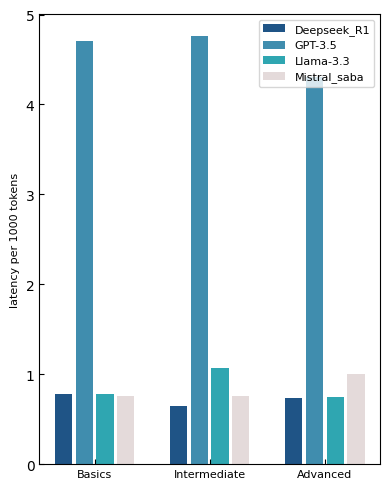

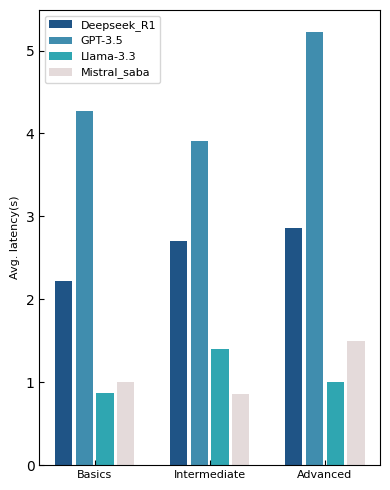

In [27]:
plot_settings(models,acc_data,model_colors,"Accuracy(%)")
plot_settings(models,hal_data,model_colors,"Hallucination(%)")
plot_settings(models, err_code, model_colors, "Coding error(%)")
plot_settings(models, token_data,model_colors,"Total Tokens")
plot_settings(models,time_per1000token_data,model_colors,"latency per 1000 tokens")
plot_settings(models, avg_latency, model_colors, "Avg. latency(s)")

In [10]:
# model wise error
def model_wise_err(model_total_err, sizes, model_code_err, model_hal_err):
    code_err_total=0
    hal_err = 0
    total_error_model = np.sum(np.array(model_total_err))
    total_queries = np.sum(np.array(sizes))
    code_err_total = np.dot(np.array(model_code_err),np.array(sizes))
    hal_err += np.dot(np.array(model_hal_err),np.array(sizes)) 
    return [total_error_model/total_queries*100,hal_err/total_queries,code_err_total/total_queries]


In [11]:
ds_total = model_wise_err(ds_total_err,sizes, ds_code_err,ds_hal)
gpt_total = model_wise_err(gpt_total_err,sizes, gpt_code_err,gpt_hal)
llama_total = model_wise_err(llama_total_err,sizes, llama_code_err,llama_hal)
mistral_total = model_wise_err(mst_total_err,sizes, mst_code_err,mst_hal)
print(ds_total)
print(gpt_total)
print(llama_total)
print(mistral_total)

[np.float64(51.61290322580645), np.float64(16.129032258064516), np.float64(65.51612903225806)]
[np.float64(74.19354838709677), np.float64(67.74193548387096), np.float64(38.70967741935484)]
[np.float64(58.06451612903226), np.float64(54.83870967741935), np.float64(29.0)]
[np.float64(74.19354838709677), np.float64(59.12903225806452), np.float64(22.580645161290324)]
